# SpaceCast — Notebook 07: Experimental Visual Playground

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*tight_layout.*")

np.random.seed(42)

# ---------------------------------------------------------------------------
# Paths (all relative to project root, resolved from notebooks/ at runtime)
# ---------------------------------------------------------------------------
NOTEBOOK_DIR = os.path.abspath("")
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
DATA_RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
RESULTS_DIR  = os.path.join(PROJECT_ROOT, "reports", "results")
PLAYGROUND_DIR = os.path.join(PROJECT_ROOT, "reports", "figures", "playground")
os.makedirs(PLAYGROUND_DIR, exist_ok=True)

print(f"Project root   : {PROJECT_ROOT}")
print(f"Data (raw)     : {DATA_RAW_DIR}")
print(f"Results        : {RESULTS_DIR}")
print(f"Playground figs: {PLAYGROUND_DIR}")

# ---------------------------------------------------------------------------
# Global style  (matches notebook 06 conventions)
# ---------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.edgecolor":     "#333333",
    "axes.linewidth":     0.9,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "#e0e0e0",
    "grid.linewidth":     0.6,
    "grid.alpha":         1.0,
    "axes.labelsize":     11,
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    9,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "#cccccc",
    "lines.linewidth":    2.0,
    "lines.markersize":   7,
    "font.family":        "sans-serif",
    "figure.dpi":         120,
    "savefig.dpi":        150,
    "savefig.bbox":       "tight",
})

# ---------------------------------------------------------------------------
# Model display conventions (identical to notebooks 05 and 06)
# ---------------------------------------------------------------------------
LABEL_MAP = {
    "persistence":  "Persistence",
    "ar24":         "AR(24)",
    "chronos2":     "Chronos-2",
    "timesfm3":     "TimesFM-3",
    "timesfm3_mv":  "TimesFM-3 MV",
}
MODEL_ORDER = ["persistence", "ar24", "chronos2", "timesfm3", "timesfm3_mv"]
MODEL_COLORS = {
    "Persistence":   "#888888",
    "AR(24)":        "#2166ac",
    "Chronos-2":     "#d6604d",
    "TimesFM-3":     "#1a9641",
    "TimesFM-3 MV":  "#7b2d8b",
}
MODEL_LINESTYLE = {
    "Persistence":   (0, (3, 1)),
    "AR(24)":        "--",
    "Chronos-2":     "-.",
    "TimesFM-3":     "-",
    "TimesFM-3 MV":  "-",
}
MODEL_MARKER = {
    "Persistence":  "s",
    "AR(24)":       "D",
    "Chronos-2":    "^",
    "TimesFM-3":    "o",
    "TimesFM-3 MV": "P",
}
HORIZONS = [1, 3, 6, 12, 24]

print("Setup complete.")

Project root   : C:\TSFM_project\SpaceCast
Data (raw)     : C:\TSFM_project\SpaceCast\data\raw
Results        : C:\TSFM_project\SpaceCast\reports\results
Playground figs: C:\TSFM_project\SpaceCast\reports\figures\playground
Setup complete.


In [2]:
# ---------------------------------------------------------------------------
# Load OMNI2 dataset and evaluation CSVs
# ---------------------------------------------------------------------------
_omni_path = os.path.join(DATA_RAW_DIR, "omni2_2016_2025_clean.csv")
if not os.path.isfile(_omni_path):
    raise FileNotFoundError(f"OMNI2 clean data not found at: {_omni_path}")

df = pd.read_csv(
    _omni_path,
    parse_dates=["datetime"],
    index_col="datetime",
    low_memory=False,
)

print(f"OMNI2 dataset: {df.shape[0]:,} rows  |  {df.index.min().date()} – {df.index.max().date()}")
print(f"Columns: {df.columns.tolist()}")

# Load evaluation CSVs
_full_path  = os.path.join(RESULTS_DIR, "tsfm_metrics_full.csv")
_univ_path  = os.path.join(RESULTS_DIR, "tsfm_metrics_univariate.csv")
_storm_path = os.path.join(RESULTS_DIR, "tsfm_metrics_dst_lt_50.csv")

for label, path in [
    ("tsfm_metrics_full.csv",       _full_path),
    ("tsfm_metrics_univariate.csv", _univ_path),
    ("tsfm_metrics_dst_lt_50.csv",  _storm_path),
]:
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Required file not found: {path}")

df_full  = pd.read_csv(_full_path)
df_univ  = pd.read_csv(_univ_path)
df_storm = pd.read_csv(_storm_path)

print(f"df_full  : {df_full.shape}")
print(f"df_univ  : {df_univ.shape}")
print(f"df_storm : {df_storm.shape}")

OMNI2 dataset: 87,672 rows  |  2016-01-01 – 2025-12-31
Columns: ['year', 'doy', 'hour', 'B_scalar_nT', 'Bx_nT', 'By_gse_nT', 'Bz_gse_nT', 'By_gsm_nT', 'Bz_gsm_nT', 'temperature_K', 'density_cm3', 'speed_km_s', 'flow_pressure_nPa', 'electric_field_mV_m', 'plasma_beta', 'alfven_mach', 'Kp10', 'Dst_nT', 'AE_nT']
df_full  : (25, 5)
df_univ  : (20, 5)
df_storm : (20, 8)


## Plot 1 — Dst Phase Portrait
State-space view of geomagnetic activity: Dst vs. its hourly rate of change (ΔDst). Each point is one hour of data. Extreme storm states (Dst < −100 nT) are highlighted in red.

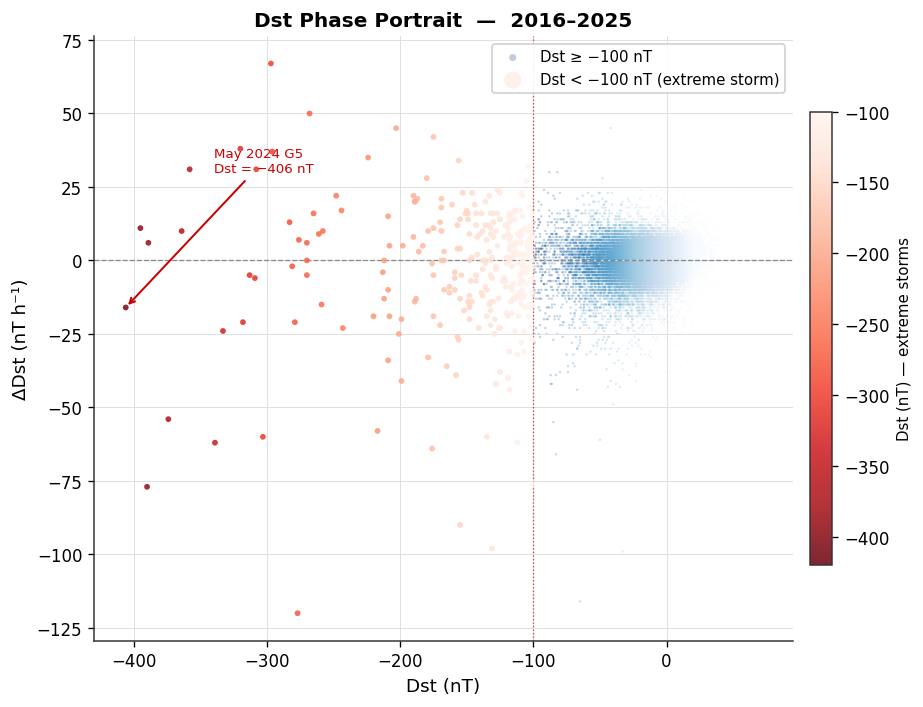

Saved: C:\TSFM_project\SpaceCast\reports\figures\playground\01_dst_phase_portrait.png


In [3]:
# ---------------------------------------------------------------------------
# Plot 1: Dst Phase Portrait
# ---------------------------------------------------------------------------
_dst = df["Dst_nT"].dropna().astype(float)
_ddst = _dst.diff().dropna()
_dst_aligned = _dst.loc[_ddst.index]

mask_normal = _dst_aligned >= -100
mask_storm  = _dst_aligned <  -100

fig, ax = plt.subplots(figsize=(8, 6))

# Background: quiet/moderate points
sc_normal = ax.scatter(
    _dst_aligned[mask_normal], _ddst[mask_normal],
    c=_dst_aligned[mask_normal], cmap="Blues_r",
    vmin=-100, vmax=20,
    s=2, alpha=0.25, linewidths=0, rasterized=True,
    label="Dst ≥ −100 nT",
)

# Foreground: extreme storm points
sc_storm = ax.scatter(
    _dst_aligned[mask_storm], _ddst[mask_storm],
    c=_dst_aligned[mask_storm], cmap="Reds_r",
    vmin=-420, vmax=-100,
    s=12, alpha=0.85, linewidths=0,
    label="Dst < −100 nT (extreme storm)",
    zorder=4,
)

cb = fig.colorbar(sc_storm, ax=ax, pad=0.02, shrink=0.75)
cb.set_label("Dst (nT) — extreme storms", fontsize=9)

ax.axhline(0, color="#333333", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(-100, color="#cc0000", linewidth=0.8, linestyle=":", alpha=0.7)

ax.set_xlabel("Dst (nT)")
ax.set_ylabel("ΔDst (nT h⁻¹)")
ax.set_title("Dst Phase Portrait  —  2016–2025")
ax.legend(loc="upper right", markerscale=3, framealpha=0.9)

# Annotate May 2024 minimum
_may_min_dst  = df.loc["2024-05-11 02:00", "Dst_nT"]
_may_min_ddst = _ddst.get(pd.Timestamp("2024-05-11 02:00"), np.nan)
if not np.isnan(_may_min_ddst):
    ax.annotate(
        "May 2024 G5\nDst = −406 nT",
        xy=(_may_min_dst, _may_min_ddst),
        xytext=(-340, 30),
        arrowprops=dict(arrowstyle="->", color="#cc0000", lw=1.2),
        fontsize=8, color="#cc0000",
    )

fig.tight_layout()
_out = os.path.join(PLAYGROUND_DIR, "01_dst_phase_portrait.png")
fig.savefig(_out)
plt.show()
print(f"Saved: {_out}")

## Plot 2 — Solar-Wind State Map
Hexbin density map of solar-wind speed vs. GSM Bz, coloured by point count. Reveals the solar-wind parameter space that drives geomagnetic disturbance; the high-speed / strongly-southward corner is sparsely populated but produces the most severe storms.

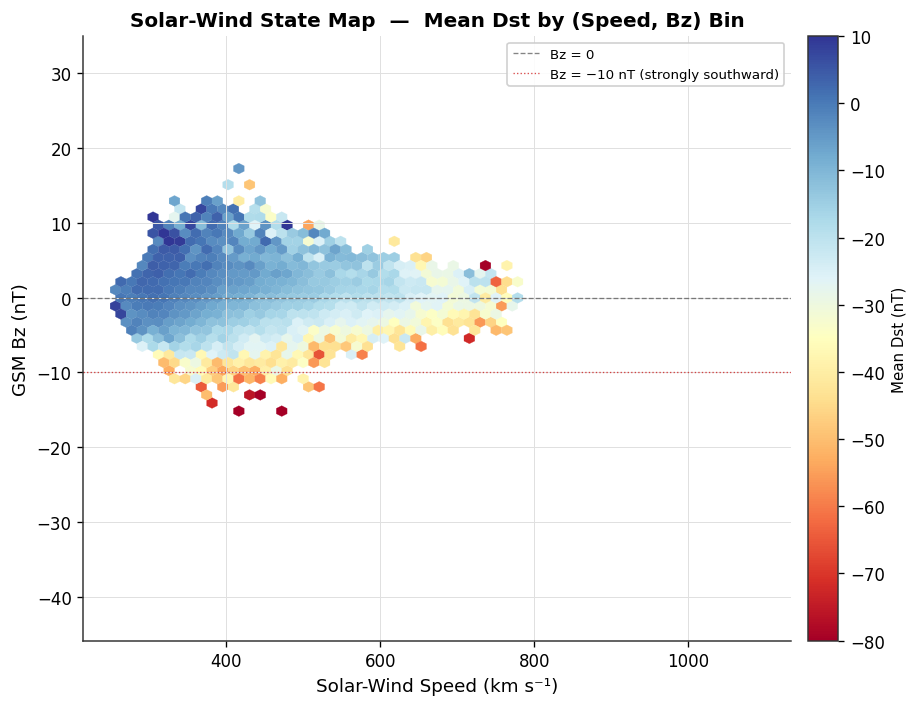

Saved: C:\TSFM_project\SpaceCast\reports\figures\playground\02_solar_wind_state_map.png


In [4]:
# ---------------------------------------------------------------------------
# Plot 2: Solar-Wind State Map (hexbin density)
# ---------------------------------------------------------------------------
_mask2 = df["speed_km_s"].notna() & df["Bz_gsm_nT"].notna()
_sw_speed = df.loc[_mask2, "speed_km_s"]
_bz       = df.loc[_mask2, "Bz_gsm_nT"]
_dst2     = df.loc[_mask2, "Dst_nT"].astype(float)

fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(
    _sw_speed, _bz,
    C=_dst2,
    reduce_C_function=np.mean,
    gridsize=60,
    cmap="RdYlBu",
    vmin=-80, vmax=10,
    linewidths=0.15,
    mincnt=5,
)

cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("Mean Dst (nT)", fontsize=9)

ax.axhline(0, color="#333333", linewidth=0.8, linestyle="--", alpha=0.6, label="Bz = 0")
ax.axhline(-10, color="#cc0000", linewidth=0.8, linestyle=":", alpha=0.7, label="Bz = −10 nT (strongly southward)")

ax.set_xlabel("Solar-Wind Speed (km s⁻¹)")
ax.set_ylabel("GSM Bz (nT)")
ax.set_title("Solar-Wind State Map  —  Mean Dst by (Speed, Bz) Bin")
ax.legend(loc="upper right", fontsize=8)

fig.tight_layout()
_out = os.path.join(PLAYGROUND_DIR, "02_solar_wind_state_map.png")
fig.savefig(_out)
plt.show()
print(f"Saved: {_out}")

## Plot 3 — 3D Solar-Wind → Geomagnetic Response State Space
3D scatter of solar-wind speed (X), GSM Bz (Y), and Dst (Z), coloured by Dst. Points are subsampled for readability. The strongly nonlinear coupling between upstream solar-wind conditions and Dst is immediately visible.

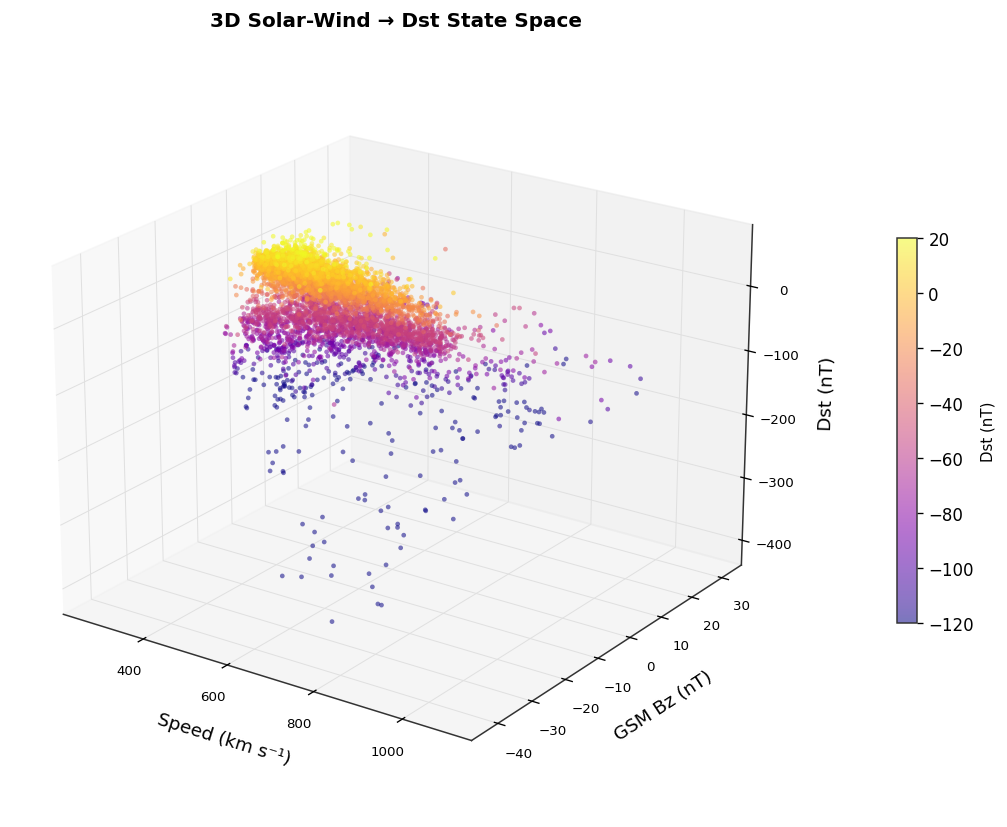

Saved: C:\TSFM_project\SpaceCast\reports\figures\playground\03_solar_wind_3d_state_space.png


In [5]:
# ---------------------------------------------------------------------------
# Plot 3: 3D solar-wind → geomagnetic response state space
# ---------------------------------------------------------------------------
_mask3 = (
    df["speed_km_s"].notna()
    & df["Bz_gsm_nT"].notna()
    & df["Dst_nT"].notna()
)
_df3 = df.loc[_mask3, ["speed_km_s", "Bz_gsm_nT", "Dst_nT"]].copy()

# Stratified subsample: keep all storm hours (Dst < -50) + random quiet sample
_storm3  = _df3[_df3["Dst_nT"] < -50]
_quiet3  = _df3[_df3["Dst_nT"] >= -50].sample(n=min(4000, len(_df3[_df3["Dst_nT"] >= -50])), random_state=42)
_df3s    = pd.concat([_storm3, _quiet3]).sample(frac=1, random_state=42)

fig = plt.figure(figsize=(10, 7))
ax3d = fig.add_subplot(111, projection="3d")

_cvals = _df3s["Dst_nT"].values
_norm  = mcolors.Normalize(vmin=-120, vmax=20)
_cmap  = plt.cm.plasma

sc3 = ax3d.scatter(
    _df3s["speed_km_s"].values,
    _df3s["Bz_gsm_nT"].values,
    _df3s["Dst_nT"].values,
    c=_cvals,
    cmap=_cmap,
    norm=_norm,
    s=8,
    alpha=0.55,
    linewidths=0,
    depthshade=True,
)

cb3 = fig.colorbar(sc3, ax=ax3d, shrink=0.5, pad=0.1)
cb3.set_label("Dst (nT)", fontsize=9)

ax3d.set_xlabel("Speed (km s⁻¹)", labelpad=8)
ax3d.set_ylabel("GSM Bz (nT)",       labelpad=8)
ax3d.set_zlabel("Dst (nT)",          labelpad=8)
ax3d.set_title("3D Solar-Wind → Dst State Space", pad=12)
ax3d.view_init(elev=22, azim=-55)

ax3d.tick_params(axis="both", labelsize=8)
ax3d.tick_params(axis="z",    labelsize=8)

fig.tight_layout()
_out = os.path.join(PLAYGROUND_DIR, "03_solar_wind_3d_state_space.png")
fig.savefig(_out)
plt.show()
print(f"Saved: {_out}")

## Plot 4 — Forecast Skill Decay
Each model’s MAE is normalised by its own 1-hour MAE. Values above 1 show how rapidly forecasting skill is lost at longer lead times. All models converge toward large relative error at 24 h, but TimesFM-3 MV degrades least.

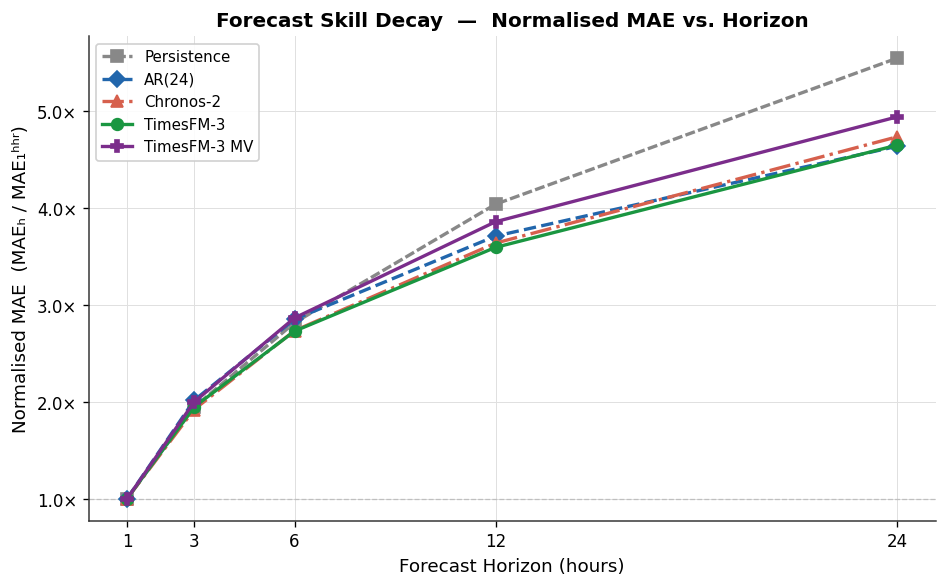

Saved: C:\TSFM_project\SpaceCast\reports\figures\playground\04_forecast_skill_decay.png


In [6]:
# ---------------------------------------------------------------------------
# Plot 4: Normalised forecast skill decay
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

for m_key in MODEL_ORDER:
    m_label = LABEL_MAP[m_key]
    sub = df_full[df_full["Model"] == m_key].sort_values("Horizon")
    if sub.empty:
        continue
    mae_h1 = sub.loc[sub["Horizon"] == 1, "MAE"].values
    if len(mae_h1) == 0 or mae_h1[0] == 0:
        continue
    norm_mae = sub["MAE"].values / mae_h1[0]
    ax.plot(
        sub["Horizon"].values,
        norm_mae,
        color=MODEL_COLORS[m_label],
        linestyle=MODEL_LINESTYLE[m_label],
        marker=MODEL_MARKER[m_label],
        label=m_label,
        zorder=4 if "MV" in m_label else 3,
    )

ax.axhline(1.0, color="#aaaaaa", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xticks(HORIZONS)
ax.set_xlabel("Forecast Horizon (hours)")
ax.set_ylabel("Normalised MAE  (MAE\u2095 / MAE₁ʰʰʳ)")
ax.set_title("Forecast Skill Decay  —  Normalised MAE vs. Horizon")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f×"))

fig.tight_layout()
_out = os.path.join(PLAYGROUND_DIR, "04_forecast_skill_decay.png")
fig.savefig(_out)
plt.show()
print(f"Saved: {_out}")

## Plot 5 — TimesFM-3 Covariate Benefit
Percentage improvement in MAE when solar-wind covariates are added to TimesFM-3 (univariate → multivariate). The benefit is largest at the shortest horizon and remains positive at all evaluated lead times.

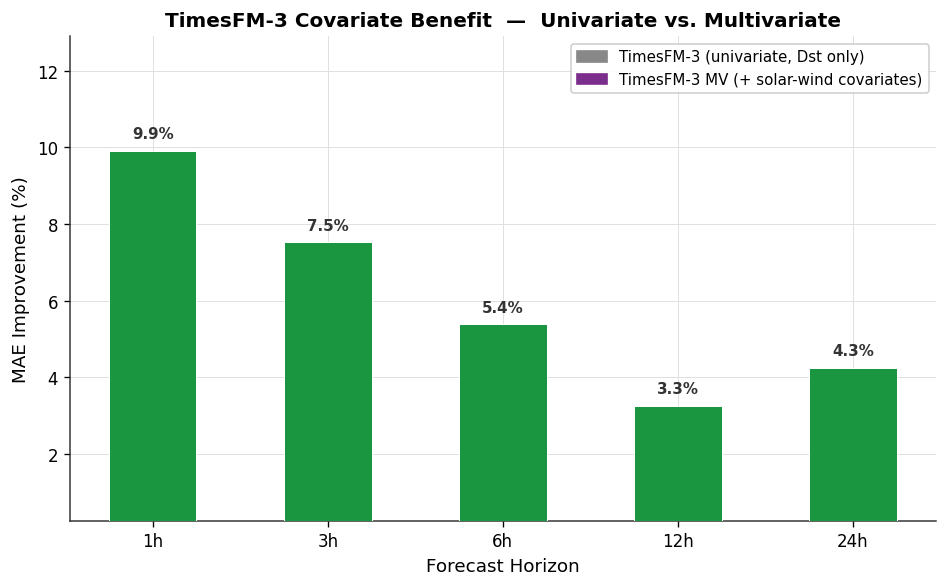

Saved: C:\TSFM_project\SpaceCast\reports\figures\playground\05_timesfm_covariate_benefit.png


In [7]:
# ---------------------------------------------------------------------------
# Plot 5: TimesFM-3 covariate benefit
# df_univ has [persistence, ar24, chronos2, timesfm3]   (no _mv)
# df_full has [persistence, ar24, chronos2, timesfm3, timesfm3_mv]
# ---------------------------------------------------------------------------
_univ_t3 = df_univ[df_univ["Model"] == "timesfm3"].sort_values("Horizon").set_index("Horizon")
_mv_t3   = df_full[df_full["Model"] == "timesfm3_mv"].sort_values("Horizon").set_index("Horizon")

_common_h = sorted(set(_univ_t3.index) & set(_mv_t3.index))

_pct_improve = [
    100.0 * (_univ_t3.loc[h, "MAE"] - _mv_t3.loc[h, "MAE"]) / _univ_t3.loc[h, "MAE"]
    for h in _common_h
]

fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = ["#1a9641" if v >= 0 else "#d6604d" for v in _pct_improve]
bars = ax.bar(
    [str(h) + "h" for h in _common_h],
    _pct_improve,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.6,
    width=0.5,
    zorder=3,
)

for bar, val in zip(bars, _pct_improve):
    yoff = 0.25 if val >= 0 else -0.6
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + yoff,
        f"{val:.1f}%",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
        color="#333333",
    )

ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("MAE Improvement (%)")
ax.set_title("TimesFM-3 Covariate Benefit  —  Univariate vs. Multivariate")
ax.set_ylim(bottom=min(_pct_improve) - 3, top=max(_pct_improve) + 3)

# Legend patches
_patch_univ = mpatches.Patch(color="#888888", label="TimesFM-3 (univariate, Dst only)")
_patch_mv   = mpatches.Patch(color="#7b2d8b", label="TimesFM-3 MV (+ solar-wind covariates)")
ax.legend(handles=[_patch_univ, _patch_mv], loc="upper right")

fig.tight_layout()
_out = os.path.join(PLAYGROUND_DIR, "05_timesfm_covariate_benefit.png")
fig.savefig(_out)
plt.show()
print(f"Saved: {_out}")

## Plot 6 — May 2024 Storm Dashboard
Three-panel event plot of the May 2024 G5 geomagnetic superstorm: solar-wind speed, GSM Bz, and Dst index. Key extreme values are annotated. This was the strongest geomagnetic storm in two decades, reaching Dst = −406 nT.

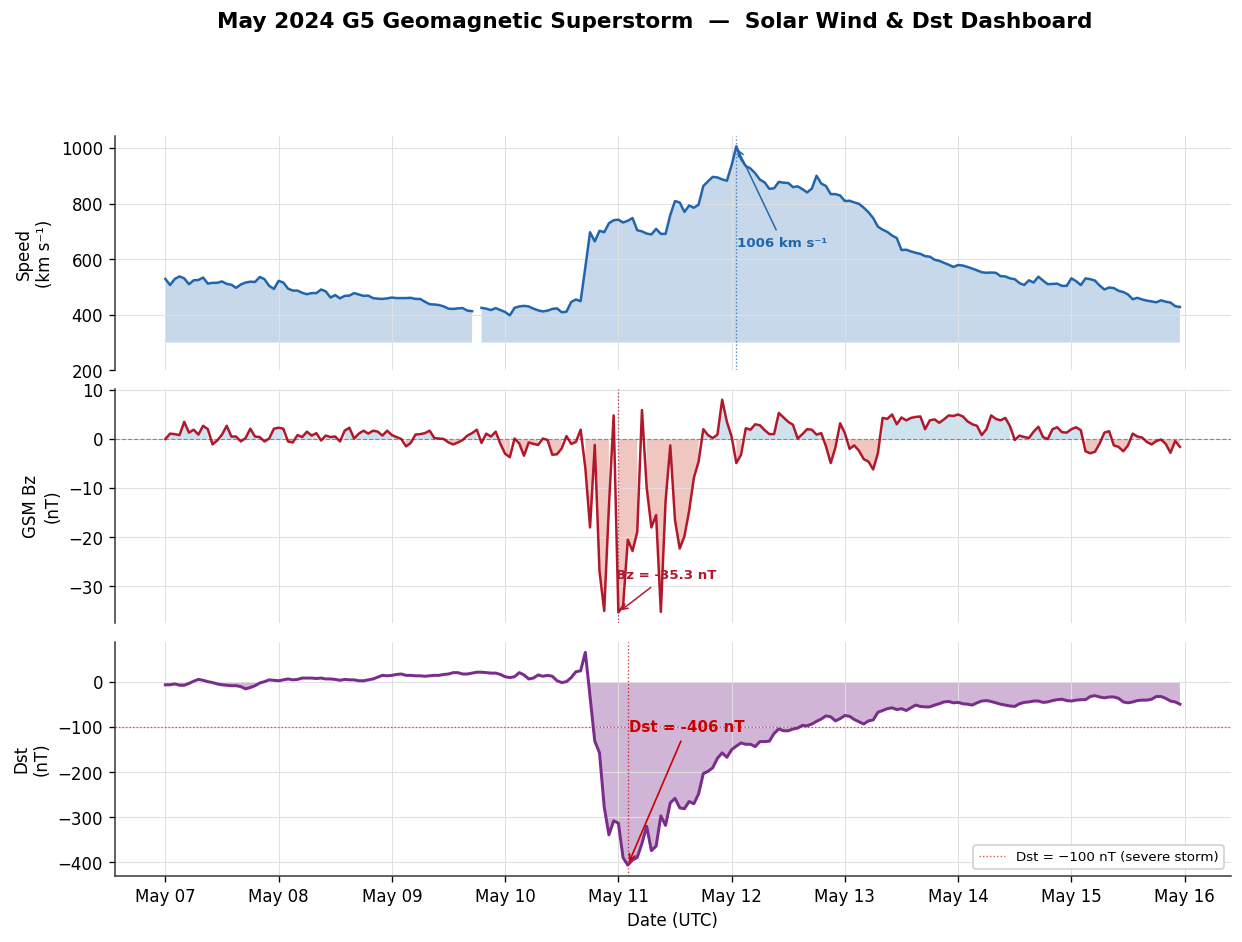

Saved: C:\TSFM_project\SpaceCast\reports\figures\playground\06_may_2024_storm_dashboard.png


In [8]:
# ---------------------------------------------------------------------------
# Plot 6: May 2024 G5 storm dashboard
# ---------------------------------------------------------------------------
_may = df.loc["2024-05-07":"2024-05-15"].copy()
_t   = _may.index

# Key events
_t_dst_min  = _may["Dst_nT"].idxmin()
_t_bz_min   = _may["Bz_gsm_nT"].idxmin()
_t_spd_max  = _may["speed_km_s"].idxmax()
_dst_min_val = _may.loc[_t_dst_min, "Dst_nT"]
_bz_min_val  = _may.loc[_t_bz_min,  "Bz_gsm_nT"]
_spd_max_val = _may.loc[_t_spd_max, "speed_km_s"]

fig = plt.figure(figsize=(12, 8))
gs  = gridspec.GridSpec(3, 1, hspace=0.08, figure=fig)

ax_spd = fig.add_subplot(gs[0])
ax_bz  = fig.add_subplot(gs[1], sharex=ax_spd)
ax_dst = fig.add_subplot(gs[2], sharex=ax_spd)

# Panel 1: Solar-wind speed
ax_spd.fill_between(_t, _may["speed_km_s"], 300, where=_may["speed_km_s"].notna(),
                    color="#2166ac", alpha=0.25, linewidth=0)
ax_spd.plot(_t, _may["speed_km_s"], color="#2166ac", linewidth=1.5)
ax_spd.axvline(_t_spd_max, color="#2166ac", linewidth=0.8, linestyle=":", alpha=0.8)
ax_spd.annotate(
    f"{_spd_max_val:.0f} km s\u207b\u00b9",
    xy=(_t_spd_max, _spd_max_val),
    xytext=(pd.Timedelta("12h"), -60),
    textcoords="offset points",
    fontsize=8, color="#2166ac", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#2166ac", lw=0.9),
)
ax_spd.set_ylabel("Speed\n(km s\u207b\u00b9)", fontsize=10)
ax_spd.set_ylim(bottom=200)
ax_spd.spines["bottom"].set_visible(False)
ax_spd.tick_params(bottom=False)
plt.setp(ax_spd.get_xticklabels(), visible=False)

# Panel 2: GSM Bz
ax_bz.fill_between(_t, _may["Bz_gsm_nT"], 0,
                   where=_may["Bz_gsm_nT"].notna() & (_may["Bz_gsm_nT"] < 0),
                   color="#d6604d", alpha=0.35, linewidth=0)
ax_bz.fill_between(_t, _may["Bz_gsm_nT"], 0,
                   where=_may["Bz_gsm_nT"].notna() & (_may["Bz_gsm_nT"] >= 0),
                   color="#4393c3", alpha=0.25, linewidth=0)
ax_bz.plot(_t, _may["Bz_gsm_nT"], color="#b2182b", linewidth=1.5)
ax_bz.axhline(0, color="#333333", linewidth=0.7, linestyle="--", alpha=0.5)
ax_bz.axvline(_t_bz_min, color="#b2182b", linewidth=0.8, linestyle=":", alpha=0.8)
ax_bz.annotate(
    f"Bz = {_bz_min_val:.1f} nT",
    xy=(_t_bz_min, _bz_min_val),
    xytext=(pd.Timedelta("-36h"), 20),
    textcoords="offset points",
    fontsize=8, color="#b2182b", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#b2182b", lw=0.9),
)
ax_bz.set_ylabel("GSM Bz\n(nT)", fontsize=10)
ax_bz.spines["bottom"].set_visible(False)
ax_bz.tick_params(bottom=False)
plt.setp(ax_bz.get_xticklabels(), visible=False)

# Panel 3: Dst
ax_dst.fill_between(_t, _may["Dst_nT"], 0,
                    where=_may["Dst_nT"].notna() & (_may["Dst_nT"] < 0),
                    color="#7b2d8b", alpha=0.35, linewidth=0)
ax_dst.plot(_t, _may["Dst_nT"], color="#7b2d8b", linewidth=1.8)
ax_dst.axhline(-100, color="#cc0000", linewidth=0.8, linestyle=":",
               alpha=0.7, label="Dst = \u2212100 nT (severe storm)")
ax_dst.axvline(_t_dst_min, color="#cc0000", linewidth=0.8, linestyle=":", alpha=0.8)
ax_dst.annotate(
    f"Dst = {_dst_min_val} nT",
    xy=(_t_dst_min, _dst_min_val),
    xytext=(pd.Timedelta("18h"), 80),
    textcoords="offset points",
    fontsize=9, color="#cc0000", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#cc0000", lw=1.0),
)
ax_dst.set_ylabel("Dst\n(nT)", fontsize=10)
ax_dst.set_xlabel("Date (UTC)", fontsize=10)
ax_dst.legend(loc="lower right", fontsize=8)
ax_dst.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%b %d"))
ax_dst.xaxis.set_major_locator(matplotlib.dates.DayLocator())
plt.setp(ax_dst.get_xticklabels(), rotation=0, ha="center")

fig.suptitle("May 2024 G5 Geomagnetic Superstorm  \u2014  Solar Wind & Dst Dashboard",
             fontsize=13, fontweight="bold", y=1.01)

# Remove top spines for shared-axis panels
for _ax in [ax_spd, ax_bz, ax_dst]:
    _ax.spines["top"].set_visible(False)
    _ax.spines["right"].set_visible(False)

fig.tight_layout()
_out = os.path.join(PLAYGROUND_DIR, "06_may_2024_storm_dashboard.png")
fig.savefig(_out)
plt.show()
print(f"Saved: {_out}")

## Plot 7 — Long-Term Geomagnetic Activity Map
Year × month heatmap of mean Dst over 2016–2025. Each cell represents one calendar month; darker purple indicates stronger geomagnetic activity. The solar-cycle dependence and clustering of severe storms near solar maximum is clearly visible.

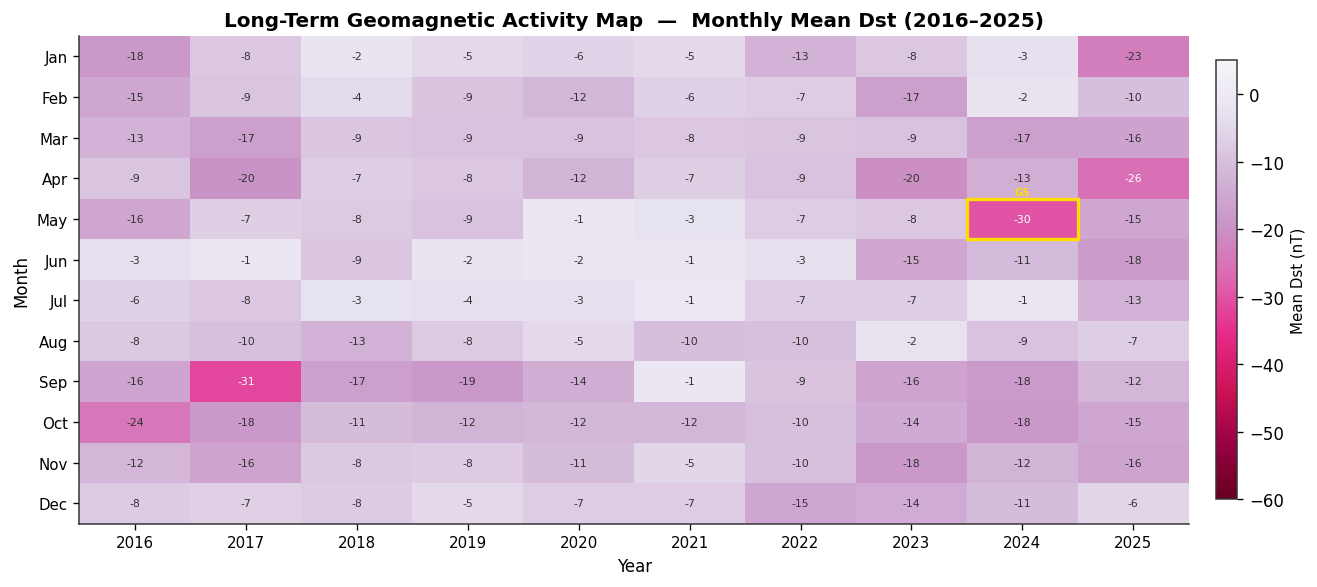

Saved: C:\TSFM_project\SpaceCast\reports\figures\playground\07_long_term_activity_map.png


In [9]:
# ---------------------------------------------------------------------------
# Plot 7: Long-term geomagnetic activity calendar heatmap
# ---------------------------------------------------------------------------
_df7 = df.copy()
_df7["year"]  = _df7.index.year
_df7["month"] = _df7.index.month

# Monthly mean Dst
_monthly_mean = (
    _df7.groupby(["year", "month"])["Dst_nT"]
    .mean()
    .reset_index()
    .rename(columns={"Dst_nT": "mean_Dst"})
)

# Pivot: rows = month (1-12), cols = year
_pivot = _monthly_mean.pivot(index="month", columns="year", values="mean_Dst")

MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(
    _pivot.values,
    aspect="auto",
    cmap="PuRd_r",
    vmin=-60, vmax=5,
    interpolation="nearest",
)

cb = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.9)
cb.set_label("Mean Dst (nT)", fontsize=9)

# Axes
_years = sorted(_pivot.columns.tolist())
ax.set_xticks(range(len(_years)))
ax.set_xticklabels([str(y) for y in _years], fontsize=9)
ax.set_yticks(range(12))
ax.set_yticklabels(MONTH_NAMES, fontsize=9)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Month", fontsize=10)
ax.set_title("Long-Term Geomagnetic Activity Map  —  Monthly Mean Dst (2016–2025)",
             fontsize=12, fontweight="bold")

# Annotate each cell with value
for r in range(_pivot.shape[0]):
    for c in range(_pivot.shape[1]):
        val = _pivot.values[r, c]
        if np.isnan(val):
            continue
        text_color = "white" if val < -25 else "#333333"
        ax.text(
            c, r, f"{val:.0f}",
            ha="center", va="center",
            fontsize=6.5, color=text_color,
        )

# Highlight the May 2024 cell
from matplotlib.patches import Rectangle
_may_col = _years.index(2024)
_may_row = 4  # May = month index 4 (0-based)
ax.add_patch(Rectangle(
    (_may_col - 0.5, _may_row - 0.5), 1, 1,
    linewidth=2, edgecolor="#ffdd00", facecolor="none", zorder=5,
))
ax.text(
    _may_col, _may_row - 0.65, "G5",
    ha="center", va="center", fontsize=6, color="#ffdd00", fontweight="bold",
)

ax.grid(False)

fig.tight_layout()
_out = os.path.join(PLAYGROUND_DIR, "07_long_term_activity_map.png")
fig.savefig(_out)
plt.show()
print(f"Saved: {_out}")

In [10]:
# ---------------------------------------------------------------------------
# Verify all 7 output files exist
# ---------------------------------------------------------------------------
_expected = [
    "01_dst_phase_portrait.png",
    "02_solar_wind_state_map.png",
    "03_solar_wind_3d_state_space.png",
    "04_forecast_skill_decay.png",
    "05_timesfm_covariate_benefit.png",
    "06_may_2024_storm_dashboard.png",
    "07_long_term_activity_map.png",
]

print("Figure verification:")
all_ok = True
for fname in _expected:
    fpath = os.path.join(PLAYGROUND_DIR, fname)
    exists = os.path.isfile(fpath)
    size_kb = os.path.getsize(fpath) / 1024 if exists else 0
    status = f"OK  ({size_kb:.1f} KB)" if exists else "MISSING"
    if not exists:
        all_ok = False
    print(f"  {'[OK]' if exists else '[MISSING]'}  {fname:45s}  {status}")

print()
print(f"All figures present: {all_ok}")

Figure verification:
  [OK]  01_dst_phase_portrait.png                      OK  (147.1 KB)
  [OK]  02_solar_wind_state_map.png                    OK  (104.7 KB)
  [OK]  03_solar_wind_3d_state_space.png               OK  (222.2 KB)
  [OK]  04_forecast_skill_decay.png                    OK  (90.7 KB)
  [OK]  05_timesfm_covariate_benefit.png               OK  (43.8 KB)
  [OK]  06_may_2024_storm_dashboard.png                OK  (158.7 KB)
  [OK]  07_long_term_activity_map.png                  OK  (77.8 KB)

All figures present: True


# Playground Complete

These are exploratory visualizations built from the SpaceCast OMNI2 dataset (2016–2025) and the saved model evaluation results in `reports/results/`.